In [3]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches


def find_repo_root(start: Path, path_entries: list[str]) -> Path:
    checked = set()
    search_roots = [start.resolve()]

    for entry in path_entries:
        if not entry:
            continue
        try:
            search_roots.append(Path(entry).resolve())
        except OSError:
            continue

    for root in search_roots:
        for candidate in [root, *root.parents]:
            candidate_str = str(candidate)
            if candidate_str in checked:
                continue
            checked.add(candidate_str)
            if (candidate / "src" / "cnt_project").exists() and (candidate / "notebooks").exists():
                return candidate

    raise RuntimeError(
        f"Could not infer repository root from cwd={start} or the current sys.path entries."
    )


REPO_ROOT = find_repo_root(Path.cwd(), sys.path)
SRC_ROOT = REPO_ROOT / "src"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from cnt_project.io.paths import ProjectPaths

PATHS = ProjectPaths.from_here(SRC_ROOT / "cnt_project" / "io" / "paths.py")
PATHS.ensure_outputs()

print("Project root:", PATHS.project_root)
print("Outputs root:", PATHS.outputs_root)

Project root: C:\Users\abd93000\PycharmProjects\cnt_project_v2
Outputs root: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs


# INPUT GT
* TIF labels
* json labels

In [4]:
FILTERED_ARTIFACTS_ROOT = PATHS.data_root / "annotations_uniques"
FILTERED_TEST_ROOT = FILTERED_ARTIFACTS_ROOT / "test"
FILTERED_TEST_IMAGES_ROOT = FILTERED_TEST_ROOT / "images"
FILTERED_TEST_MASKS_ROOT = FILTERED_TEST_ROOT / "masks"
FILTERED_TEST_COCO_JSON = FILTERED_TEST_ROOT / "COCO_mask" / "annotations.json"

SAMPLE_IMAGE_NAME = "400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.jpg"
SAMPLE_MASK_NAME = "400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.tif"

input_gt_json_path = FILTERED_TEST_COCO_JSON
path_image = FILTERED_TEST_IMAGES_ROOT / SAMPLE_IMAGE_NAME
path_mask = FILTERED_TEST_MASKS_ROOT / SAMPLE_MASK_NAME

output_pred_json_path = PATHS.outputs_root / "nano1D_annotations_filtered_artifacts" / "predicted_annotations.json"

In [5]:

with open(input_gt_json_path) as f:
    coco = json.load(f)

image_id_to_filename = {img['id']: img['file_name'] for img in coco['images']}
areas = []
for ann in coco['annotations']:
    area = ann['bbox'][2] * ann['bbox'][3]  # width * height
    areas.append((area, ann['image_id'], ann['id'], ann['bbox']))
    
areas.sort(key=lambda x: x[0], reverse=True)

print("Top 10 largest objects by area:")
for i, (area, image_id, ann_id, bbox) in enumerate(areas[:10], 1):
    filename = image_id_to_filename.get(image_id, 'Unknown')
    print(f"{i}. Image: {filename},ID: {image_id}, Annotation ID: {ann_id}, Area: {area:.2f}, BBox: {bbox}")

Top 10 largest objects by area:
1. Image: 400-1605-W3_map_00034_1.jpg,ID: 21, Annotation ID: 2411, Area: 15960.00, BBox: [151, 0, 105, 152]
2. Image: 400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.jpg,ID: 13, Annotation ID: 1804, Area: 15851.00, BBox: [21, 36, 121, 131]
3. Image: 400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left.jpg,ID: 8, Annotation ID: 1183, Area: 13500.00, BBox: [4, 72, 108, 125]
4. Image: 400-1605-W8_map_00038_3.jpg,ID: 27, Annotation ID: 2728, Area: 12288.00, BBox: [163, 0, 48, 256]
5. Image: 400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.jpg,ID: 13, Annotation ID: 1898, Area: 7743.00, BBox: [51, 118, 87, 89]
6. Image: 400-1093-w17-c1p3-20sp-03flow_right.jpg,ID: 6, Annotation ID: 1025, Area: 7314.00, BBox: [0, 33, 53, 138]
7. Image: 400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.jpg,ID: 13, Annotation ID: 1806, Area: 6283.00, BBox: [10, 22, 103, 61]
8. Image: 400-1605-W3_map_00041_1.jpg,ID: 23, Annotation ID: 2544, Area: 5986.00, BBox: [212, 50, 41, 146]
9. Image: 400-1093-w17-

JSON LABESL

C:\Users\abd93000\AppData\Local\Temp\ipykernel_26448\3276743976.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 5)


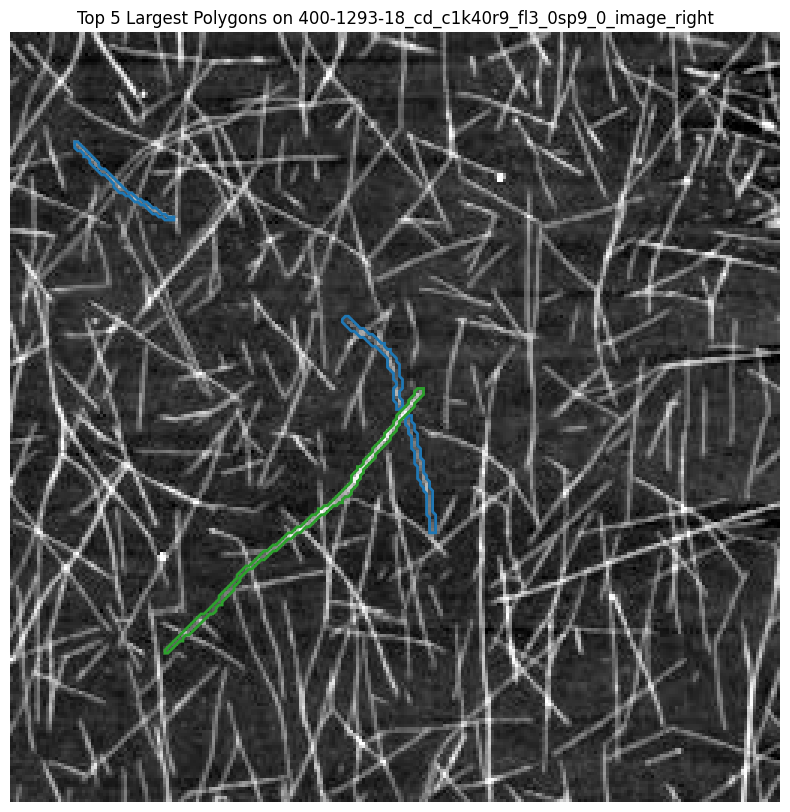

In [6]:
from PIL import Image

# Load COCO JSON
with open(input_gt_json_path) as f:
    coco = json.load(f)

# Filter annotations for the given image (match by filename without extension)
image_filename = path_image.stem

# Find the COCO image_id for this filename
image_id = None
for img in coco['images']:
    if Path(img['file_name']).stem == image_filename:
        image_id = img['id']
        break

if image_id is None:
    raise ValueError(f"Image {image_filename} not found in annotations")

# Filter annotations for this image
anns_for_image = [ann for ann in coco['annotations'] if ann['image_id'] == image_id]

# Sort annotations by bbox area descending
anns_for_image.sort(key=lambda ann: ann['bbox'][2] * ann['bbox'][3], reverse=True)

# Load image
img = Image.open(path_image)

# Plot image and top 5 polygons
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img)
ax.set_axis_off()

colors = plt.cm.get_cmap('tab10', 5)

for i, ann in enumerate(anns_for_image[:2]):
    segmentation = ann.get('segmentation', [])
    color = colors(i)
    for polygon in segmentation:
        if isinstance(polygon, list):
            xy = [(polygon[j], polygon[j+1]) for j in range(0, len(polygon), 2)]
            patch = patches.Polygon(xy, closed=True, linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(patch)

plt.title(f"Top 5 Largest Polygons on {image_filename}")
plt.show()

Verify that the largest area (bbox) are made out of continuous CNTs

C:\Users\abd93000\AppData\Local\Temp\ipykernel_26448\3660818863.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)  # 10 distinct colors


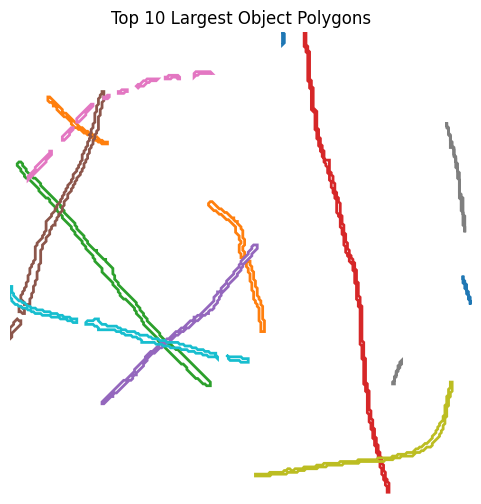

In [7]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# Load COCO JSON
with open(input_gt_json_path) as f:
    coco = json.load(f)

# Calculate areas and store polygons
areas = []
for ann in coco['annotations']:
    area = ann['bbox'][2] * ann['bbox'][3]
    segmentation = ann.get('segmentation', [])
    areas.append((area, segmentation))

# Sort descending by area
areas.sort(key=lambda x: x[0], reverse=True)

# Prepare figure with fixed size
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 256)  # width
ax.set_ylim(0, 256)  # height
ax.set_aspect('equal')
ax.invert_yaxis()  # To match image coordinate system (origin top-left)
ax.set_title("Top 10 Largest Object Polygons")
ax.axis('off')

colors = plt.cm.get_cmap('tab10', 10)  # 10 distinct colors

# Plot polygons for top 10 largest objects
for i, (area, segmentation) in enumerate(areas[:10]):
    color = colors(i)
    for polygon in segmentation:
        if isinstance(polygon, list):
            # Convert flat list to (x,y) tuples
            xy = [(polygon[j], polygon[j+1]) for j in range(0, len(polygon), 2)]
            patch = patches.Polygon(xy, closed=True, linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(patch)

plt.show()

TIF LABELS

Verify that tiff labels are appropriate
For exemple, this one is not

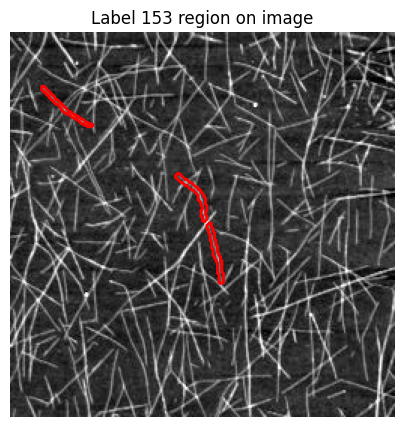

In [8]:
# Load image
img = Image.open(path_image)

# Load mask as uint16 (assuming you updated mask format to uint16)
mask = np.array(Image.open(path_mask))

label_id = 153

# Create a mask of the target label
label_mask = (mask == label_id)

# Find contours of the label region to plot polygon(s)
from skimage import measure

contours = measure.find_contours(label_mask.astype(float), 0.5)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img)
ax.set_axis_off()

# Plot contours as polygons
for contour in contours:
    # contour is Nx2 array of coordinates (row, col), swap to (x,y)
    poly = patches.Polygon(contour[:, [1, 0]], closed=True, edgecolor='red', linewidth=2, facecolor='none')
    ax.add_patch(poly)

plt.title(f"Label {label_id} region on image")
plt.show()

# OUTPUT PRED

In [13]:
output_pred_json_path = PATHS.runs_root / "nano1D" / "predicted_annotations.json"

C:\Users\abd93000\AppData\Local\Temp\ipykernel_26448\978551375.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 5)
C:\Users\abd93000\AppData\Local\Temp\ipykernel_26448\978551375.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


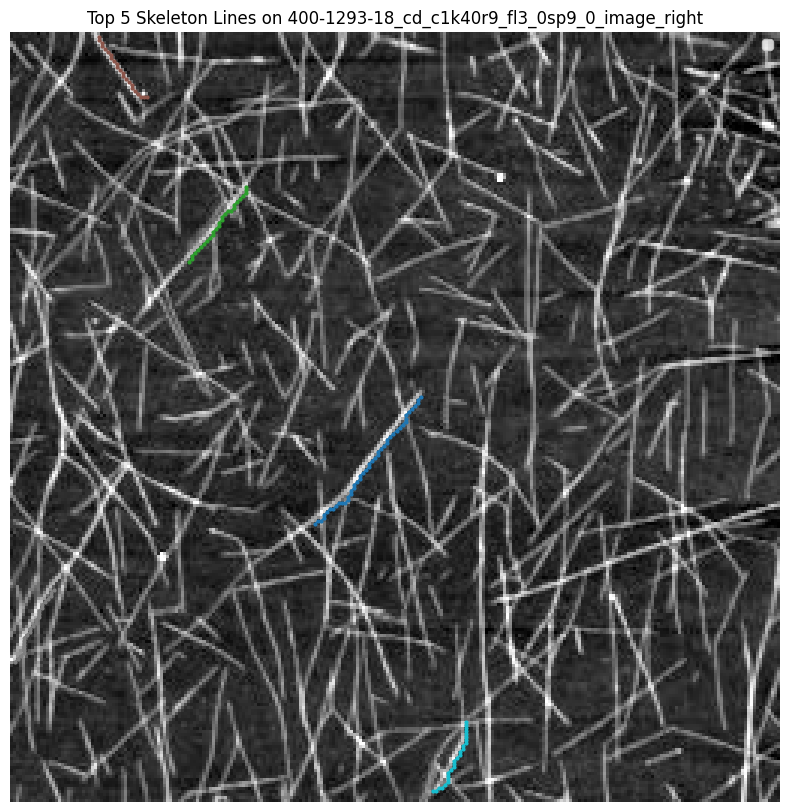

In [14]:
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# Load COCO JSON
with open(output_pred_json_path) as f:
    coco = json.load(f)

# Extract image filename without extension
image_filename = path_image.stem

# Get image ID from COCO
image_id = None
for img in coco['images']:
    if Path(img['file_name']).stem == image_filename:
        image_id = img['id']
        break

if image_id is None:
    raise ValueError(f"Image {image_filename} not found in annotations")

# Filter and sort annotations by bbox area
anns_for_image = [ann for ann in coco['annotations'] if ann['image_id'] == image_id]
anns_for_image.sort(key=lambda ann: ann['bbox'][2] * ann['bbox'][3], reverse=True)

# Load image
img = Image.open(path_image)

# Plot image with top N skeleton lines
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img)
ax.set_axis_off()

colors = plt.cm.get_cmap('tab10', 5)

for i, ann in enumerate(anns_for_image[:5]):
    segmentation = ann.get('segmentation', [])
    color = colors(i)
    for polyline in segmentation:
        if isinstance(polyline, list) and len(polyline) >= 4:
            x = polyline[::2]
            y = polyline[1::2]
            ax.plot(x, y, color=color, linewidth=1, marker='o', markersize=2)

plt.title(f"Top 5 Skeleton Lines on {image_filename}")
plt.legend()
plt.show()